/tmp/ipykernel_1061/2257533029.py:87: RuntimeWarning: invalid value encountered in subtract
  t_prime = (4.0 * u_n1 - u_n2) / 3.0


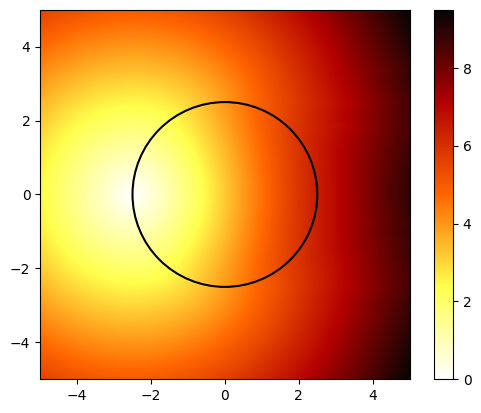

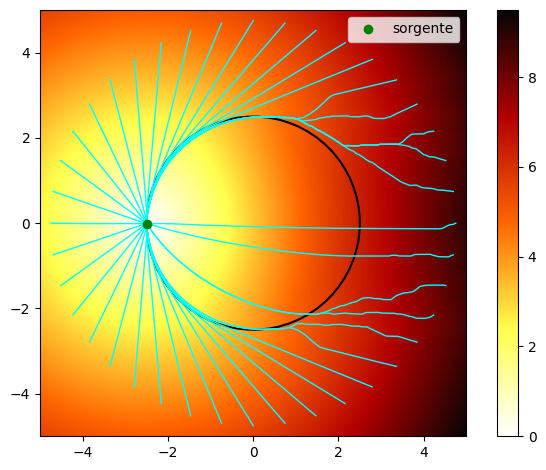

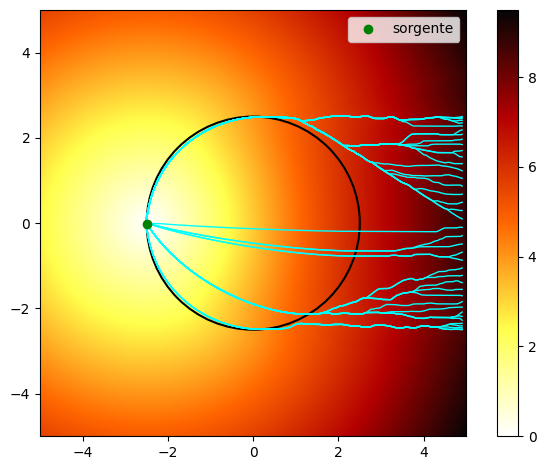

In [ ]:
## VERSIONE FIM con raggio e interpolazione spline adattiva ##

## QUESTO CODICE è UNA PROVA, QUELLO CHE FUNZIONA STA NELLA CASELLA DI CODICE SUCCESSIVA##

#------------------  LIBRERIE --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import distance_transform_edt
# from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------
nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

#------------------  CAMPO DI VELOCITA' (LENTE DI LUNEBURG) --------------------
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), np.ones(X.shape).T,
                                    method='linear', bounds_error=False, fill_value=None)

# --- parametri della lente ---
R_lens = 2.5        # raggio della lente di Luneburg
xc, yc = 0.0, 0.0   # centro della lente (nell'origine del dominio)
rho = np.sqrt((X - xc)**2 + (Y - yc)**2)
inside = rho < R_lens

n_luneburg = np.ones(X.shape)
n_luneburg[inside] = np.sqrt(2.0 - (rho[inside] / R_lens)**2)

F = np.ones(X.shape)
F = 1 / n_luneburg   # F è la VELOCITA', reciproca dell'indice di rifrazione
F[inside] = 1 / np.sqrt(2.0 - (rho[inside] / R_lens)**2)

wall_mask = np.isinf(F)

#punto iniziale (sorgente) — nel fuoco, cioè sul bordo della lente
ix0 = np.argmin(np.abs(x - (xc - R_lens)))   # colonna corrispondente a x = xc - R_lens
iy0 = np.argmin(np.abs(y - yc))              # riga corrispondente a y = yc

source_pt = (x[ix0], y[iy0])   # coordinate fisiche della sorgente (il fuoco della lente)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0
# ==============================================================================
# CALCOLO FIM
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

#------------------ GODUNOV 2 --------------------------------------------------

def _dir_contribution(u0, u_n1, u_n2, valid1, valid2, alpha, alpha_prime):

    use = valid1 & (u0 > u_n1)

    second_ok = use & valid2 & (u_n2 < u_n1)
    first_ok  = use & ~second_ok

    t_prime = (4.0 * u_n1 - u_n2) / 3.0
    beta2   = -2.0 * alpha_prime * t_prime
    gamma2  = alpha_prime * (t_prime ** 2)

    beta1  = -(2.0 * u_n1 * alpha)
    gamma1 = (u_n1 ** 2) * alpha

    a_c = np.where(second_ok, alpha_prime, np.where(first_ok, alpha, 0.0))
    b_c = np.where(second_ok, beta2,       np.where(first_ok, beta1, 0.0))
    c_c = np.where(second_ok, gamma2,      np.where(first_ok, gamma1, 0.0))

    return a_c, b_c, c_c


def Godunov_update_2nd(T, F, row, col):

    u0 = T[row, col]

    def neighbor(rr, cc, axis_len_r=nRows, axis_len_c=nCols):
        rr_c = np.clip(rr, 0, axis_len_r - 1)
        cc_c = np.clip(cc, 0, axis_len_c - 1)
        return rr_c, cc_c

    # --- direzione riga meno (i-1, i-2) ---
    r_m1, r_m2 = row - 1, row - 2
    rc1, _ = neighbor(r_m1, col)
    rc2, _ = neighbor(r_m2, col)
    valid_m1 = (r_m1 >= 0) & ~wall_mask[rc1, col]
    valid_m2 = valid_m1 & (r_m2 >= 0) & ~wall_mask[rc2, col]
    u_rm1, u_rm2 = T[rc1, col], T[rc2, col]

    # --- direzione riga più (i+1, i+2) ---
    r_p1, r_p2 = row + 1, row + 2
    rc1, _ = neighbor(r_p1, col)
    rc2, _ = neighbor(r_p2, col)
    valid_p1 = (r_p1 < nRows) & ~wall_mask[rc1, col]
    valid_p2 = valid_p1 & (r_p2 < nRows) & ~wall_mask[rc2, col]
    u_rp1, u_rp2 = T[rc1, col], T[rc2, col]

    # --- direzione colonna meno (j-1, j-2) ---
    c_m1, c_m2 = col - 1, col - 2
    _, cc1 = neighbor(row, c_m1)
    _, cc2 = neighbor(row, c_m2)
    valid_cm1 = (c_m1 >= 0) & ~wall_mask[row, cc1]
    valid_cm2 = valid_cm1 & (c_m2 >= 0) & ~wall_mask[row, cc2]
    u_cm1, u_cm2 = T[row, cc1], T[row, cc2]

    # --- direzione colonna più (j+1, j+2) ---
    c_p1, c_p2 = col + 1, col + 2
    _, cc1 = neighbor(row, c_p1)
    _, cc2 = neighbor(row, c_p2)
    valid_cp1 = (c_p1 < nCols) & ~wall_mask[row, cc1]
    valid_cp2 = valid_cp1 & (c_p2 < nCols) & ~wall_mask[row, cc2]
    u_cp1, u_cp2 = T[row, cc1], T[row, cc2]

    alpha       = 1.0 / (h ** 2)
    alpha_prime = 9.0 / (4.0 * h ** 2)

    a = np.zeros_like(u0)
    b = np.zeros_like(u0)
    c = -(1/F[row, col] ** 2) * np.ones_like(u0)

    for u_n1, u_n2, v1, v2 in [
        (u_rm1, u_rm2, valid_m1, valid_m2),
        (u_rp1, u_rp2, valid_p1, valid_p2),
        (u_cm1, u_cm2, valid_cm1, valid_cm2),
        (u_cp1, u_cp2, valid_cp1, valid_cp2),
    ]:
        a_c, b_c, c_c = _dir_contribution(u0, u_n1, u_n2, v1, v2, alpha, alpha_prime)
        a += a_c
        b += b_c
        c += c_c

    disc = b ** 2 - 4.0 * a * c

    safe_a = np.where(a == 0, 1.0, a)          # evita divisione per zero
    u_quad = (-b + np.sqrt(np.maximum(disc, 0.0))) / (2.0 * safe_a)
    u_lin  = -b / (2.0 * safe_a)               # ramo "not isreal" del MATLAB

    u_new = np.where(disc >= 0, u_quad, u_lin)
    u_new = np.where(a == 0, u0, u_new)        # nessun vicino valido: resta invariato

    return np.minimum(u0, u_new)

#------------------  AGGIORNAMENTO FIM -----------------------------------------

def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update_2nd(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update_2nd(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)

# Plot campo iconale
from matplotlib.patches import Circle

# definisci la colormap PRIMA di usarla
stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)   # puoi passarla direttamente qui
plt.colorbar(im, ax=ax)

# disegna il contorno della lente
circ = Circle((xc, yc), R_lens, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(circ)

plt.show()

# ==============================================================================
# CALCOLO RAGGI CON INTERPOLAZIONE SPLINE ADATTIVA
# ==============================================================================

#------------------  CALCOLO DEI POLINOMI CUBICI HERMITIANI --------------------

def hermite_basis(s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2
    return h00, h10, h01, h11

def hermite_basis_deriv(s):
    h00p = 6*s**2 - 6*s
    h10p = 3*s**2 - 4*s + 1
    h01p = -6*s**2 + 6*s
    h11p = 3*s**2 - 2*s
    return h00p, h10p, h01p, h11p

#------------------  INTERPOLAZIONE HERMITIANA ---------------------------------

#controlla se i punti all'estrama dx-sx sono oltre un muro, in caso lo fossero
#non avrebbero significato, li scarta e ricorre alla forward/backward bi-sided
def hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=False, wall_p2=False):
    if wall_m1:
        m0 = (f_1 - f_0) / h          # forward difference
    else:
        m0 = (f_1 - f_m1) / (2*h)     # differenza centrata

    if wall_p2:
        m1 = (f_1 - f_0) / h          # backward difference
    else:
        m1 = (f_2 - f_0) / (2*h)      # differenza centrata

    h00, h10, h01, h11 = hermite_basis(s)
    val = h00*f_0 + h10*h*m0 + h01*f_1 + h11*h*m1

    h00p, h10p, h01p, h11p = hermite_basis_deriv(s)
    dval_ds = h00p*f_0 + h10p*h*m0 + h01p*f_1 + h11p*h*m1
    dval_dx = dval_ds / h

    return val, dval_dx

#controlla se i punti subito a dx-sx sono un muro, in caso lo fossero esegue
#la forward/backward one-sided
def hermite_1d_or_fallback(f_m1, f_0, f_1, f_2, s, h,
                            wall_m1=False, wall_p2=False,
                            wall_0=False, wall_1=False):
    if wall_0 and wall_1: #entrambi muro, valore non significativo
        return 0.5*(f_0+f_1), 0.0

    if wall_1 and not wall_0: #muro a dx, uso backward
        deriv = (f_0 - f_m1) / h if not wall_m1 else 0.0
        return f_0, deriv

    if wall_0 and not wall_1: #muro a sx, uso forward
        deriv = (f_2 - f_1) / h if not wall_p2 else 0.0
        return f_1, deriv

    #se è libero chiamo hermite
    return hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=wall_m1, wall_p2=wall_p2)

#------------------  UTILITY FUNCTION ------------------------------------------

#ulteriore guard che serve a clippare gli indici che escono dai bordi
def clamp_index(j, n):
    return min(max(j, 1), n - 3)

#serve a restituire true se il punto (row,col) è un muro o è fuori dai bordi ed
#è utilizzata dalle funzioni hermitiane per controllare dove hanno il muro
def is_wall_rc(row, col, wall_mask):
    nrows, ncols = wall_mask.shape
    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return True
    return bool(wall_mask[row, col])

def is_wall_at(pt, F, x, y):
    col = np.clip(np.searchsorted(x, pt[0])- 1 , 0, F.shape[1] - 1)
    row = np.clip(np.searchsorted(y, pt[1]) - 1 , 0, F.shape[0] - 1)
    return np.isinf(F[row, col])

#------------------  INTERPOLAZIONE SPLINE -------------------------------------

#restituisce le dT/dx dT/dy interpolate tramite spline
def bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy):
    px, py = pt
    nrows, ncols = T_field.shape

    jx = int(np.floor((px - x[0]) / dx))
    jy = int(np.floor((py - y[0]) / dy))

    jx = clamp_index(jx, ncols)
    jy = clamp_index(jy, nrows)

    sx = (px - x[jx]) / dx
    sy = (py - y[jy]) / dy

    # passo 1: interpola sui 4 nodi lungo x ottenendo T(xq, yk) e dT(xq,yk)/dx
    # per le k = {1..4} colonne di y.
    g_val = np.empty(4)
    g_dx  = np.empty(4)
    for k, ry in enumerate((-1, 0, 1, 2)):
        row = jy + ry
        f_m1 = T_field[row, jx - 1] if jx - 1 >= 0 else T_field[row, jx]
        f_0  = T_field[row, jx]
        f_1  = T_field[row, jx + 1]
        f_2  = T_field[row, jx + 2] if jx + 2 < ncols else T_field[row, jx + 1]

        wall_left  = is_wall_rc(row, jx - 1, wall_mask)
        wall_right = is_wall_rc(row, jx + 2, wall_mask)
        wall_0     = is_wall_rc(row, jx, wall_mask)
        wall_1     = is_wall_rc(row, jx + 1, wall_mask)

        g_val[k], g_dx[k] = hermite_1d_or_fallback(
            f_m1, f_0, f_1, f_2, sx, dx,
            wall_m1=wall_left, wall_p2=wall_right,
            wall_0=wall_0, wall_1=wall_1)

    # passo 2: interpola sui 4 nodi lungo y in modo da calcolare e correggere le
    # derivate rispetto al punto fisico xq, ottenendo finalemente dT(xq,yq)/dx e
    # dT(xq,yq)/dy
    wall_down = is_wall_rc(jy - 1, jx, wall_mask) or is_wall_rc(jy - 1, jx + 1, wall_mask)
    wall_up   = is_wall_rc(jy + 2, jx, wall_mask) or is_wall_rc(jy + 2, jx + 1, wall_mask)
    wall_0y   = is_wall_rc(jy, jx, wall_mask) or is_wall_rc(jy, jx + 1, wall_mask)
    wall_1y   = is_wall_rc(jy + 1, jx, wall_mask) or is_wall_rc(jy + 1, jx + 1, wall_mask)

    _, dT_dy = hermite_1d_or_fallback(g_val[0], g_val[1], g_val[2], g_val[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)
    dT_dx, _ = hermite_1d_or_fallback(g_dx[0], g_dx[1], g_dx[2], g_dx[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)

    return dT_dx, dT_dy

#------------------  NORMALIZZAZIONE DEL GRADIENTE -----------------------------

def grad_at_local(pt, T_field, wall_mask, x, y, dx, dy):
    gx, gy = bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy)
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    norm = np.sqrt(gx**2 + gy**2)
    if norm < 1e-12:
        return np.array([0.0, 0.0])
    scale = 1.0 / norm   # forza |grad T| = 1 (coerente con F=1 fuori dai muri)
    return np.array([gx * scale, gy * scale])

#------------------  RUNGE-KUTTA 4°ORDINE --------------------------------------

def trace_ray_rk4(start_pt, T_field, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy):
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        k1 = -grad_at_local(pt, T_field, wall_mask, x, y, dx, dy)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at_local(pt + 0.5*ds*k1, T_field, wall_mask, x, y, dx, dy)
        k3 = -grad_at_local(pt + 0.5*ds*k2, T_field, wall_mask, x, y, dx, dy)
        k4 = -grad_at_local(pt + ds*k3, T_field, wall_mask, x, y, dx, dy)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        step_ds = ds
        pt_new = pt + step_ds * dpt
        n_tries = 0
        while is_wall_at(pt_new, F, x, y) and n_tries < 8:
            step_ds *= 0.5
            pt_new = pt + step_ds * dpt
            n_tries += 1

        ray.append(pt_new.copy())

        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  FASCIO DI RAGGI IN TUTTE LE DIREZIONI ----------------------

n_rays = 40                      # numero di raggi nel fascio
R_exit = sidex * 0.95            # raggio del cerchio di "uscita" (vicino al bordo dominio)
angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False)

ds = dx/2
max_steps = 10000

rays_fan = []
for theta in np.linspace(0, 2*np.pi, 40, endpoint=False):
    exit_pt = (R_exit*np.cos(theta), R_exit*np.sin(theta))
    rays_fan.append(trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy))

y_exits = R_lens * np.sin(np.linspace(-np.pi/2*0.98, np.pi/2*0.98, n_rays))
# uso di sin() per infittire vicino agli estremi invece che uniforme

x_exit = R_lens + 2.4
rays_collim = []
for y_e in y_exits:
    exit_pt = (x_exit, y_e)
    ray = trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy)
    rays_collim.append(ray)
#------------------  PLOT FASCIO ------------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

circ = Circle((xc, yc), R_lens, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(circ)

for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)

ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

circ = Circle((xc, yc), R_lens, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(circ)

# plotta QUESTI, non il vecchio "rays"
for ray in rays_collim:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)

ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()

rays_fan_hermite = rays_fan
rays_collim_hermite = rays_collim
T_final_hermite = T_final

/tmp/ipykernel_1061/51897238.py:81: RuntimeWarning: invalid value encountered in subtract
  t_prime = (4.0 * u_n1 - u_n2) / 3.0


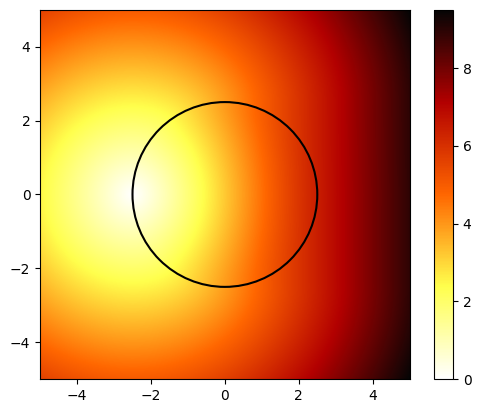

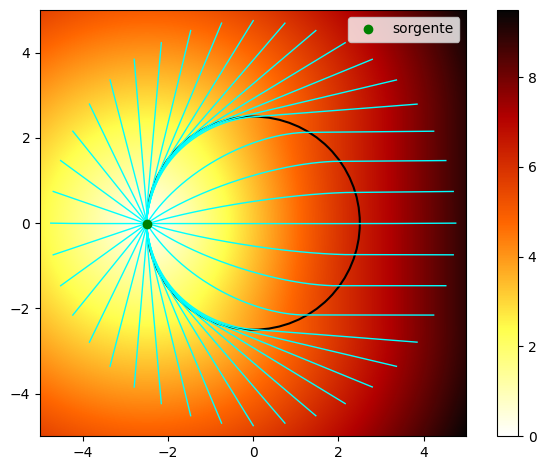

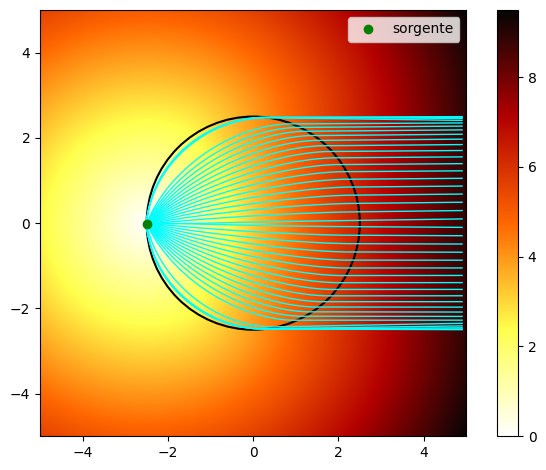

In [ ]:
## VERSIONE FIM con raggio e interpolazione spline adattiva ##


#------------------  LIBRERIE --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import distance_transform_edt
# from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------
nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)

#------------------  CAMPO DI VELOCITA' (LENTE DI LUNEBURG) --------------------
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), np.ones(X.shape).T,
                                    method='linear', bounds_error=False, fill_value=None)

# --- parametri della lente ---
R_lens = 2.5        # raggio della lente di Luneburg
xc, yc = 0.0, 0.0   # centro della lente (nell'origine del dominio)
rho = np.sqrt((X - xc)**2 + (Y - yc)**2)
inside = rho < R_lens

n_luneburg = np.ones(X.shape)
n_luneburg[inside] = np.sqrt(2.0 - (rho[inside] / R_lens)**2)

F = np.ones(X.shape)
F = 1.0 / n_luneburg   # F è la VELOCITA', reciproca dell'indice di rifrazione
F[inside] = 1.0 / np.sqrt(2.0 - (rho[inside] / R_lens)**2)

wall_mask = np.isinf(F)

#punto iniziale (sorgente) — nel fuoco, cioè sul bordo della lente
ix0 = np.argmin(np.abs(x - (xc - R_lens)))   # colonna corrispondente a x = xc - R_lens
iy0 = np.argmin(np.abs(y - yc))              # riga corrispondente a y = yc

source_pt = (x[ix0], y[iy0])   # coordinate fisiche della sorgente (il fuoco della lente)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

# ==============================================================================
# CALCOLO FIM
# ==============================================================================

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx


def _dir_contribution(u0, u_n1, u_n2, valid1, valid2, alpha, alpha_prime):

    use = valid1 & (u0 > u_n1)

    second_ok = use & valid2 & (u_n2 < u_n1)
    first_ok  = use & ~second_ok

    t_prime = (4.0 * u_n1 - u_n2) / 3.0
    beta2   = -2.0 * alpha_prime * t_prime
    gamma2  = alpha_prime * (t_prime ** 2)

    beta1  = -(2.0 * u_n1 * alpha)
    gamma1 = (u_n1 ** 2) * alpha

    a_c = np.where(second_ok, alpha_prime, np.where(first_ok, alpha, 0.0))
    b_c = np.where(second_ok, beta2,       np.where(first_ok, beta1, 0.0))
    c_c = np.where(second_ok, gamma2,      np.where(first_ok, gamma1, 0.0))

    return a_c, b_c, c_c


def Godunov_update_2nd(T, F, row, col):

    u0 = T[row, col]

    def neighbor(rr, cc, axis_len_r=nRows, axis_len_c=nCols):
        rr_c = np.clip(rr, 0, axis_len_r - 1)
        cc_c = np.clip(cc, 0, axis_len_c - 1)
        return rr_c, cc_c

    # --- direzione riga meno (i-1, i-2) ---
    r_m1, r_m2 = row - 1, row - 2
    rc1, _ = neighbor(r_m1, col)
    rc2, _ = neighbor(r_m2, col)
    valid_m1 = (r_m1 >= 0) & ~wall_mask[rc1, col]
    valid_m2 = valid_m1 & (r_m2 >= 0) & ~wall_mask[rc2, col]
    u_rm1, u_rm2 = T[rc1, col], T[rc2, col]

    # --- direzione riga più (i+1, i+2) ---
    r_p1, r_p2 = row + 1, row + 2
    rc1, _ = neighbor(r_p1, col)
    rc2, _ = neighbor(r_p2, col)
    valid_p1 = (r_p1 < nRows) & ~wall_mask[rc1, col]
    valid_p2 = valid_p1 & (r_p2 < nRows) & ~wall_mask[rc2, col]
    u_rp1, u_rp2 = T[rc1, col], T[rc2, col]

    # --- direzione colonna meno (j-1, j-2) ---
    c_m1, c_m2 = col - 1, col - 2
    _, cc1 = neighbor(row, c_m1)
    _, cc2 = neighbor(row, c_m2)
    valid_cm1 = (c_m1 >= 0) & ~wall_mask[row, cc1]
    valid_cm2 = valid_cm1 & (c_m2 >= 0) & ~wall_mask[row, cc2]
    u_cm1, u_cm2 = T[row, cc1], T[row, cc2]

    # --- direzione colonna più (j+1, j+2) ---
    c_p1, c_p2 = col + 1, col + 2
    _, cc1 = neighbor(row, c_p1)
    _, cc2 = neighbor(row, c_p2)
    valid_cp1 = (c_p1 < nCols) & ~wall_mask[row, cc1]
    valid_cp2 = valid_cp1 & (c_p2 < nCols) & ~wall_mask[row, cc2]
    u_cp1, u_cp2 = T[row, cc1], T[row, cc2]

    alpha       = 1.0 / (h ** 2)
    alpha_prime = 9.0 / (4.0 * h ** 2)

    a = np.zeros_like(u0)
    b = np.zeros_like(u0)
    c = -(1/F[row, col] ** 2) * np.ones_like(u0)

    for u_n1, u_n2, v1, v2 in [
        (u_rm1, u_rm2, valid_m1, valid_m2),
        (u_rp1, u_rp2, valid_p1, valid_p2),
        (u_cm1, u_cm2, valid_cm1, valid_cm2),
        (u_cp1, u_cp2, valid_cp1, valid_cp2),
    ]:
        a_c, b_c, c_c = _dir_contribution(u0, u_n1, u_n2, v1, v2, alpha, alpha_prime)
        a += a_c
        b += b_c
        c += c_c

    disc = b ** 2 - 4.0 * a * c

    safe_a = np.where(a == 0, 1.0, a)          # evita divisione per zero
    u_quad = (-b + np.sqrt(np.maximum(disc, 0.0))) / (2.0 * safe_a)
    u_lin  = -b / (2.0 * safe_a)               # ramo "not isreal" del MATLAB

    u_new = np.where(disc >= 0, u_quad, u_lin)
    u_new = np.where(a == 0, u0, u_new)        # nessun vicino valido: resta invariato

    return np.minimum(u0, u_new)

def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update_2nd(T, F, row, col)

        T[row, col] = q

        converged_cond = np.abs(p - q) < 1e-6
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)


# Plot campo iconale
from matplotlib.patches import Circle

# definisci la colormap PRIMA di usarla
stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)   # puoi passarla direttamente qui
plt.colorbar(im, ax=ax)

# disegna il contorno della lente
circ = Circle((xc, yc), R_lens, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(circ)

plt.show()

# ==============================================================================
# CALCOLO RAGGI CON INTERPOLAZIONE SPLINE ADATTIVA
# ==============================================================================

#------------------  CALCOLO DEI POLINOMI CUBICI HERMITIANI --------------------

def hermite_basis(s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2
    return h00, h10, h01, h11

def hermite_basis_deriv(s):
    h00p = 6*s**2 - 6*s
    h10p = 3*s**2 - 4*s + 1
    h01p = -6*s**2 + 6*s
    h11p = 3*s**2 - 2*s
    return h00p, h10p, h01p, h11p

#------------------  INTERPOLAZIONE HERMITIANA ---------------------------------

#controlla se i punti all'estrama dx-sx sono oltre un muro, in caso lo fossero
#non avrebbero significato, li scarta e ricorre alla forward/backward bi-sided
def hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=False, wall_p2=False):
    if wall_m1:
        m0 = (f_1 - f_0) / h          # forward difference
    else:
        m0 = (f_1 - f_m1) / (2*h)     # differenza centrata

    if wall_p2:
        m1 = (f_1 - f_0) / h          # backward difference
    else:
        m1 = (f_2 - f_0) / (2*h)      # differenza centrata

    h00, h10, h01, h11 = hermite_basis(s)
    val = h00*f_0 + h10*h*m0 + h01*f_1 + h11*h*m1

    h00p, h10p, h01p, h11p = hermite_basis_deriv(s)
    dval_ds = h00p*f_0 + h10p*h*m0 + h01p*f_1 + h11p*h*m1
    dval_dx = dval_ds / h

    return val, dval_dx

#controlla se i punti subito a dx-sx sono un muro, in caso lo fossero esegue
#la forward/backward one-sided
def hermite_1d_or_fallback(f_m1, f_0, f_1, f_2, s, h,
                            wall_m1=False, wall_p2=False,
                            wall_0=False, wall_1=False):
    if wall_0 and wall_1: #entrambi muro, valore non significativo
        return 0.5*(f_0+f_1), 0.0

    if wall_1 and not wall_0: #muro a dx, uso backward
        deriv = (f_0 - f_m1) / h if not wall_m1 else 0.0
        return f_0, deriv

    if wall_0 and not wall_1: #muro a sx, uso forward
        deriv = (f_2 - f_1) / h if not wall_p2 else 0.0
        return f_1, deriv

    #se è libero chiamo hermite
    return hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=wall_m1, wall_p2=wall_p2)

#------------------  UTILITY FUNCTION ------------------------------------------

#ulteriore guard che serve a clippare gli indici che escono dai bordi
def clamp_index(j, n):
    return min(max(j, 1), n - 3)

#serve a restituire true se il punto (row,col) è un muro o è fuori dai bordi ed
#è utilizzata dalle funzioni hermitiane per controllare dove hanno il muro
def is_wall_rc(row, col, wall_mask):
    nrows, ncols = wall_mask.shape
    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return True
    return bool(wall_mask[row, col])

def is_wall_at(pt, F, x, y):
    col = np.clip(np.searchsorted(x, pt[0])- 1 , 0, F.shape[1] - 1)
    row = np.clip(np.searchsorted(y, pt[1]) - 1 , 0, F.shape[0] - 1)
    return np.isinf(F[row, col])

#------------------  INTERPOLAZIONE SPLINE -------------------------------------

#restituisce le dT/dx dT/dy interpolate tramite spline
def bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy):
    px, py = pt
    nrows, ncols = T_field.shape

    jx = int(np.floor((px - x[0]) / dx))
    jy = int(np.floor((py - y[0]) / dy))

    jx = clamp_index(jx, ncols)
    jy = clamp_index(jy, nrows)

    sx = (px - x[jx]) / dx
    sy = (py - y[jy]) / dy

    # passo 1: interpola sui 4 nodi lungo x ottenendo T(xq, yk) e dT(xq,yk)/dx
    # per le k = {1..4} colonne di y.
    g_val = np.empty(4)
    g_dx  = np.empty(4)
    for k, ry in enumerate((-1, 0, 1, 2)):
        row = jy + ry
        f_m1 = T_field[row, jx - 1] if jx - 1 >= 0 else T_field[row, jx]
        f_0  = T_field[row, jx]
        f_1  = T_field[row, jx + 1]
        f_2  = T_field[row, jx + 2] if jx + 2 < ncols else T_field[row, jx + 1]

        wall_left  = is_wall_rc(row, jx - 1, wall_mask)
        wall_right = is_wall_rc(row, jx + 2, wall_mask)
        wall_0     = is_wall_rc(row, jx, wall_mask)
        wall_1     = is_wall_rc(row, jx + 1, wall_mask)

        g_val[k], g_dx[k] = hermite_1d_or_fallback(
            f_m1, f_0, f_1, f_2, sx, dx,
            wall_m1=wall_left, wall_p2=wall_right,
            wall_0=wall_0, wall_1=wall_1)

    # passo 2: interpola sui 4 nodi lungo y in modo da calcolare e correggere le
    # derivate rispetto al punto fisico xq, ottenendo finalemente dT(xq,yq)/dx e
    # dT(xq,yq)/dy
    wall_down = is_wall_rc(jy - 1, jx, wall_mask) or is_wall_rc(jy - 1, jx + 1, wall_mask)
    wall_up   = is_wall_rc(jy + 2, jx, wall_mask) or is_wall_rc(jy + 2, jx + 1, wall_mask)
    wall_0y   = is_wall_rc(jy, jx, wall_mask) or is_wall_rc(jy, jx + 1, wall_mask)
    wall_1y   = is_wall_rc(jy + 1, jx, wall_mask) or is_wall_rc(jy + 1, jx + 1, wall_mask)

    _, dT_dy = hermite_1d_or_fallback(g_val[0], g_val[1], g_val[2], g_val[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)
    dT_dx, _ = hermite_1d_or_fallback(g_dx[0], g_dx[1], g_dx[2], g_dx[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)

    return dT_dx, dT_dy

#------------------  NORMALIZZAZIONE DEL GRADIENTE -----------------------------

def grad_at_local(pt, T_field, wall_mask, x, y, dx, dy):
    gx, gy = bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy)
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    norm = np.sqrt(gx**2 + gy**2)
    if norm < 1e-12:
        return np.array([0.0, 0.0])
    scale = 1.0 / norm   # forza |grad T| = 1 (coerente con F=1 fuori dai muri)
    return np.array([gx * scale, gy * scale])

#------------------  RUNGE-KUTTA 4°ORDINE --------------------------------------

def trace_ray_rk4(start_pt, T_field, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy):
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        k1 = -grad_at_local(pt, T_field, wall_mask, x, y, dx, dy)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at_local(pt + 0.5*ds*k1, T_field, wall_mask, x, y, dx, dy)
        k3 = -grad_at_local(pt + 0.5*ds*k2, T_field, wall_mask, x, y, dx, dy)
        k4 = -grad_at_local(pt + ds*k3, T_field, wall_mask, x, y, dx, dy)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        step_ds = ds
        pt_new = pt + step_ds * dpt
        n_tries = 0
        while is_wall_at(pt_new, F, x, y) and n_tries < 8:
            step_ds *= 0.5
            pt_new = pt + step_ds * dpt
            n_tries += 1

        ray.append(pt_new.copy())

        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  FASCIO DI RAGGI IN TUTTE LE DIREZIONI ----------------------

n_rays = 40                      # numero di raggi nel fascio
R_exit = sidex * 0.95            # raggio del cerchio di "uscita" (vicino al bordo dominio)
angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False)

ds = dx/2
max_steps = 10000

rays_fan = []
for theta in np.linspace(0, 2*np.pi, 40, endpoint=False):
    exit_pt = (R_exit*np.cos(theta), R_exit*np.sin(theta))
    rays_fan.append(trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy))

y_exits = R_lens * np.sin(np.linspace(-np.pi/2*0.98, np.pi/2*0.98, n_rays))
# uso di sin() per infittire vicino agli estremi invece che uniforme

x_exit = R_lens + 2.4
rays_collim = []
for y_e in y_exits:
    exit_pt = (x_exit, y_e)
    ray = trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy)
    rays_collim.append(ray)
#------------------  PLOT FASCIO ------------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

circ = Circle((xc, yc), R_lens, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(circ)

for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)

ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

circ = Circle((xc, yc), R_lens, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(circ)

# plotta QUESTI, non il vecchio "rays"
for ray in rays_collim:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)

ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()

rays_fan_hermite = rays_fan
rays_collim_hermite = rays_collim
T_final_hermite = T_final